### Tugas Machine Learning Sampling dan Exploratory Data Analysis (EDA) dengan Dataset Iris

### Lusia Clara Sianturi
### 2304010019

# BAGIAN A - Eksplorasi Data Awal

Import Library & Load Dataset

In [2]:
# Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

# Load dataset Iris
iris = load_iris()

# Membuat DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Mengganti label numerik menjadi nama spesies
df['species'] = df['species'].map(dict(enumerate(iris.target_names)))

# Melihat 5 data pertama
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 1. Informasi Dataset

In [3]:
# Jumlah data dan variabel
print("Jumlah data :", df.shape[0])
print("Jumlah variabel :", df.shape[1])

# Tipe data tiap variabel
print("\nTipe Data:")
print(df.dtypes)

# Jumlah masing-masing spesies
print("\nJumlah masing-masing spesies:")
print(df['species'].value_counts())

Jumlah data : 150
Jumlah variabel : 5

Tipe Data:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

Jumlah masing-masing spesies:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 2. Statistik Deskriptif

In [6]:
# Statistik deskriptif
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Perhitungan Manual

In [19]:
numerical_cols = df.columns[:-1]

for col in numerical_cols:
    print(f"\nVariabel: {col}")
    print("Mean   :", df[col].mean())
    print("Median :", df[col].median())
    print("Std    :", df[col].std())
    print("Min    :", df[col].min())
    print("Max    :", df[col].max())


Variabel: sepal length (cm)
Mean   : 5.843333333333334
Median : 5.8
Std    : 0.8280661279778629
Min    : 4.3
Max    : 7.9

Variabel: sepal width (cm)
Mean   : 3.0573333333333337
Median : 3.0
Std    : 0.435866284936698
Min    : 2.0
Max    : 4.4

Variabel: petal length (cm)
Mean   : 3.7580000000000005
Median : 4.35
Std    : 1.7652982332594667
Min    : 1.0
Max    : 6.9

Variabel: petal width (cm)
Mean   : 1.1993333333333336
Median : 1.3
Std    : 0.7622376689603465
Min    : 0.1
Max    : 2.5


## 3a. Histogram untuk Setiap Variabel Numerik

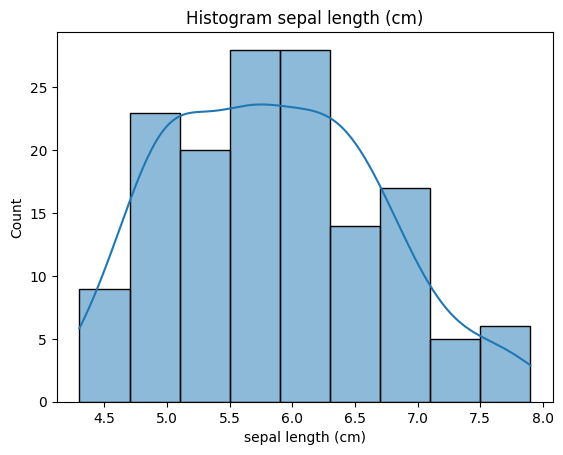

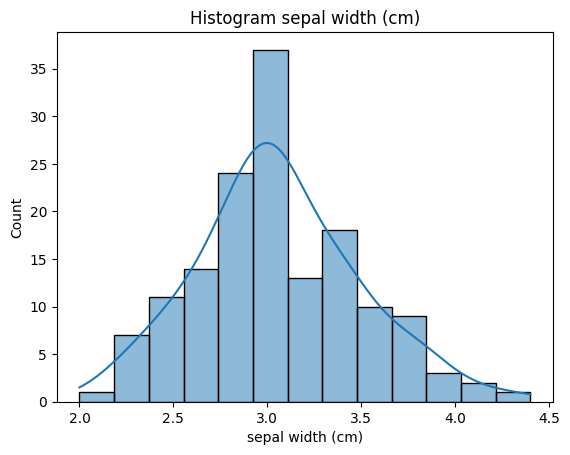

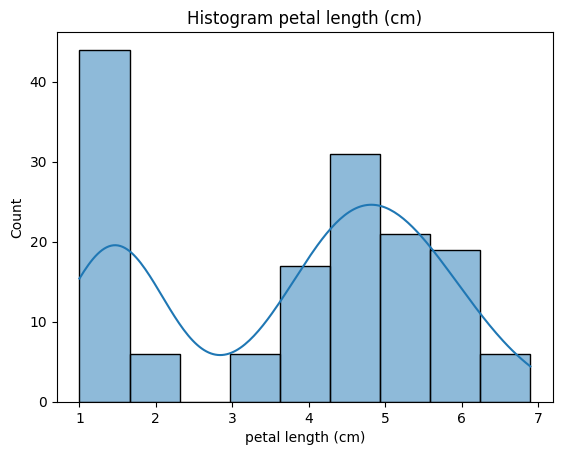

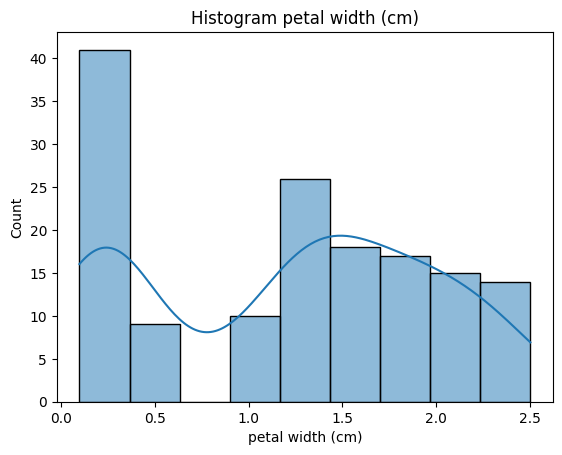

In [7]:
for col in numerical_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram {col}')
    plt.show()

## 3b. Boxplot untuk Setiap Variabel Numerik

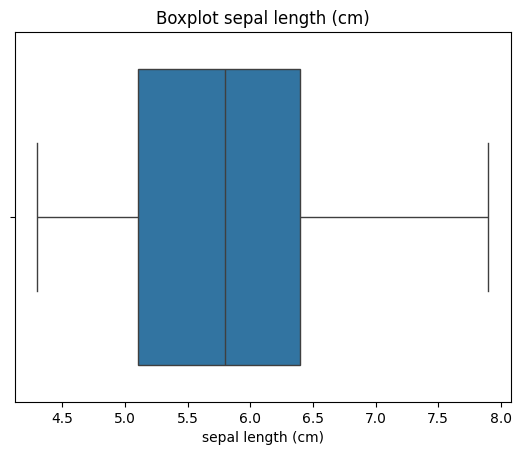

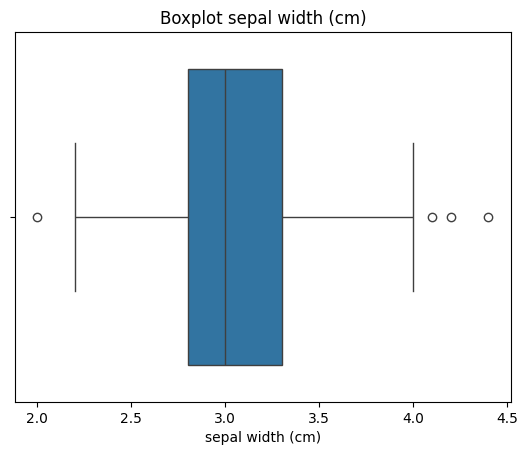

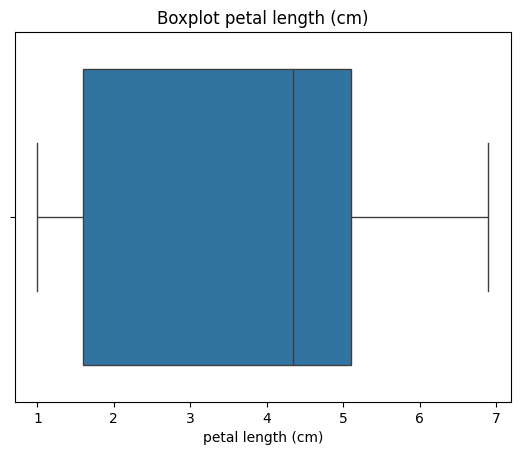

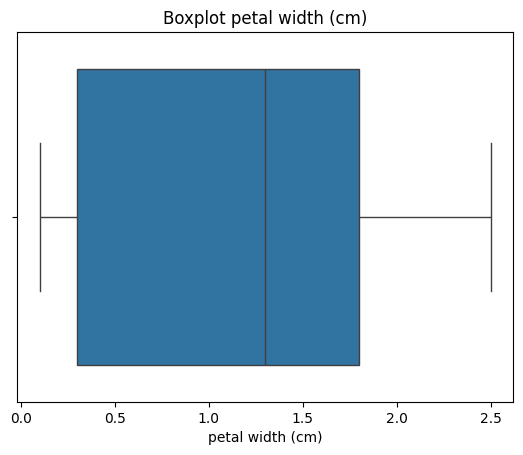

In [8]:
for col in numerical_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot {col}')
    plt.show()

**Bentuk distribusi**

Sebagian besar variabel seperti sepal length dan petal length memiliki bentuk distribusi yang mendekati normal, meskipun terlihat lebih dari satu puncak karena adanya perbedaan antar spesies. Variabel petal width juga menunjukkan pola yang cenderung multimodal (lebih dari satu kelompok). Sementara itu, sepal width sedikit tidak simetris (agak skew).

**Sebaran data**

Variabel petal length dan petal width memiliki sebaran (range) yang lebih besar dibandingkan variabel sepal, sehingga variasinya lebih tinggi dan lebih jelas membedakan spesies. Sebaran sepal width relatif lebih sempit dibandingkan variabel lainnya.

**Apakah terdapat outlier**

Berdasarkan boxplot, terdapat beberapa titik yang berada di luar whisker, terutama pada sepal width. Namun jumlahnya sedikit dan tidak ekstrem, sehingga secara keseluruhan tidak terdapat outlier yang signifikan dalam dataset.

## 4. Boxplot Per Spesies

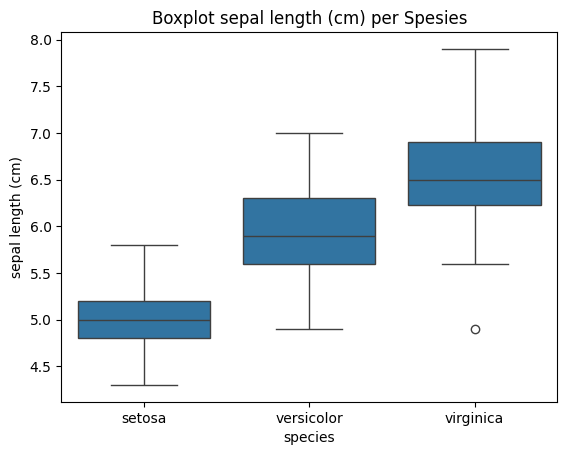

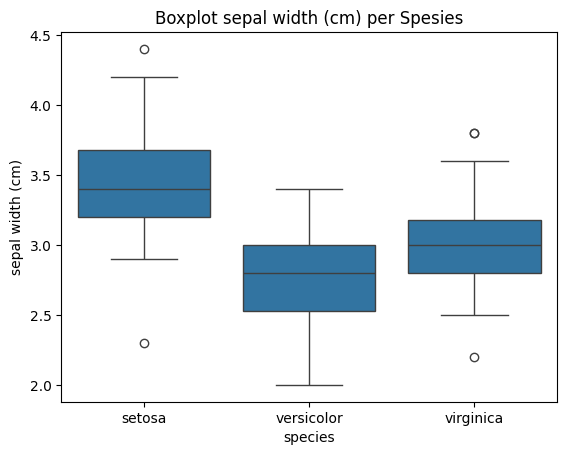

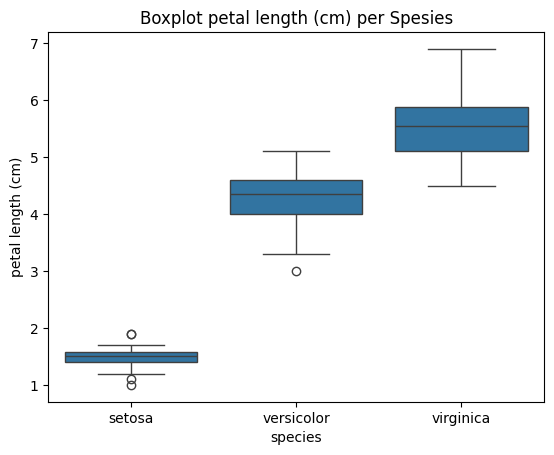

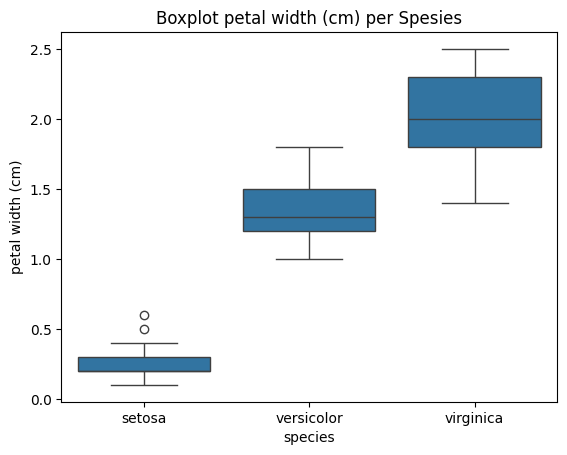

In [9]:
for col in numerical_cols:
    plt.figure()
    sns.boxplot(x='species', y=col, data=df)
    plt.title(f'Boxplot {col} per Spesies')
    plt.show()

Perbedaan antar spesies

**Setosa**

Memiliki ukuran petal length dan petal width paling kecil dibandingkan spesies lain. Distribusinya terpisah jelas dan hampir tidak overlap dengan versicolor maupun virginica, sehingga paling mudah dibedakan. Variasinya juga relatif kecil (lebih homogen).

**Versicolor**

Memiliki ukuran petal sedang, berada di antara setosa dan virginica. Terdapat sedikit overlap dengan virginica, terutama pada petal length dan petal width. Variasinya lebih besar dibanding setosa.

**Virginica**

Memiliki ukuran petal length dan petal width paling besar. Sebarannya lebih lebar dan beberapa nilainya tumpang tindih dengan versicolor, tetapi tetap dapat dibedakan dari setosa dengan sangat jelas.

# BAGIAN B - Sampling (Bootstrap)

In [12]:
petal_length = df['petal length (cm)']
n = len(petal_length)

## 1. Bootstrap Tunggal

In [13]:
# Bootstrap satu kali
bootstrap_sample = np.random.choice(petal_length, size=n, replace=True)

# Statistik bootstrap
print("Mean asli :", petal_length.mean())
print("Median asli :", petal_length.median())

print("\nMean bootstrap :", np.mean(bootstrap_sample))
print("Median bootstrap :", np.median(bootstrap_sample))

Mean asli : 3.7580000000000005
Median asli : 4.35

Mean bootstrap : 3.8833333333333333
Median bootstrap : 4.5


## 2. Bootstrap Berulang

In [20]:
def bootstrap_mean(data, n_bootstrap):
    means = []
    for i in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    return means

# Bootstrap
mean_100 = bootstrap_mean(petal_length, 100)
mean_1000 = bootstrap_mean(petal_length, 1000)
mean_10000 = bootstrap_mean(petal_length, 10000)

In [22]:
print("Mean asli:", np.mean(petal_length))

print("\n=== Bootstrap 100 kali ===")
print("Rata-rata mean:", np.mean(mean_100))
print("Std dari mean:", np.std(mean_100))

print("\n=== Bootstrap 1000 kali ===")
print("Rata-rata mean:", np.mean(mean_1000))
print("Std dari mean:", np.std(mean_1000))

print("\n=== Bootstrap 10000 kali ===")
print("Rata-rata mean:", np.mean(mean_10000))
print("Std dari mean:", np.std(mean_10000))

Mean asli: 3.7580000000000005

=== Bootstrap 100 kali ===
Rata-rata mean: 3.776193333333333
Std dari mean: 0.15486904274257007

=== Bootstrap 1000 kali ===
Rata-rata mean: 3.747576
Std dari mean: 0.13953456203313136

=== Bootstrap 10000 kali ===
Rata-rata mean: 3.7579782666666666
Std dari mean: 0.14205621005978977


## 3a. Histogram Distribusi Mean Bootstrap

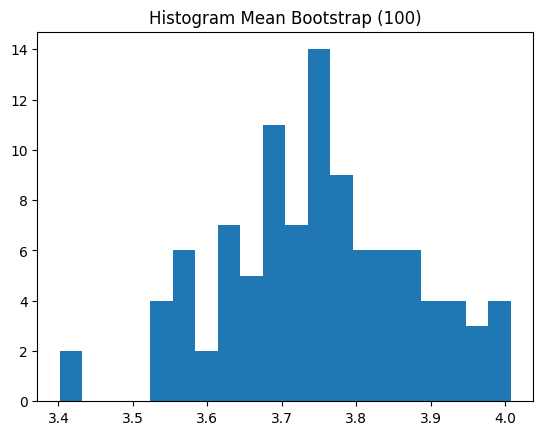

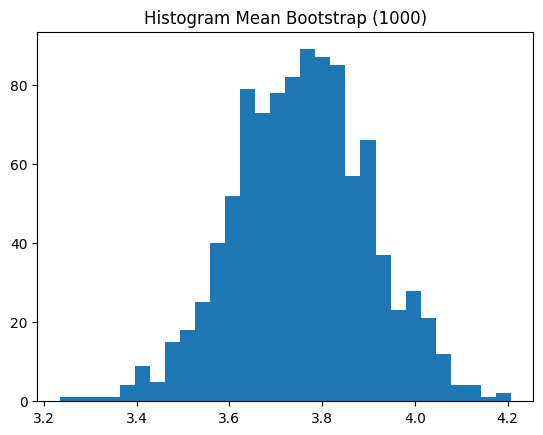

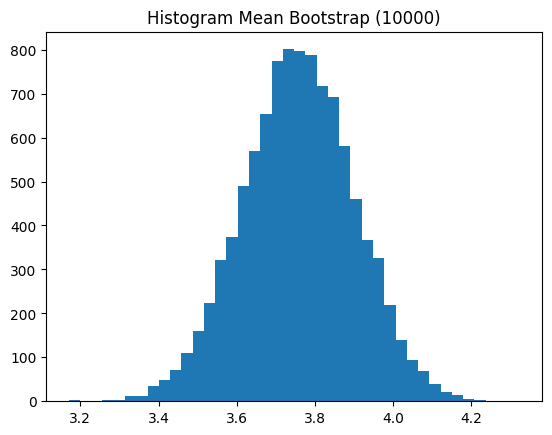

In [15]:
plt.figure()
plt.hist(mean_100, bins=20)
plt.title("Histogram Mean Bootstrap (100)")
plt.show()

plt.figure()
plt.hist(mean_1000, bins=30)
plt.title("Histogram Mean Bootstrap (1000)")
plt.show()

plt.figure()
plt.hist(mean_10000, bins=40)
plt.title("Histogram Mean Bootstrap (10000)")
plt.show()

## 3b. Boxplot Mean Bootstrap

/tmp/ipython-input-160/3736527705.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([mean_100, mean_1000, mean_10000],


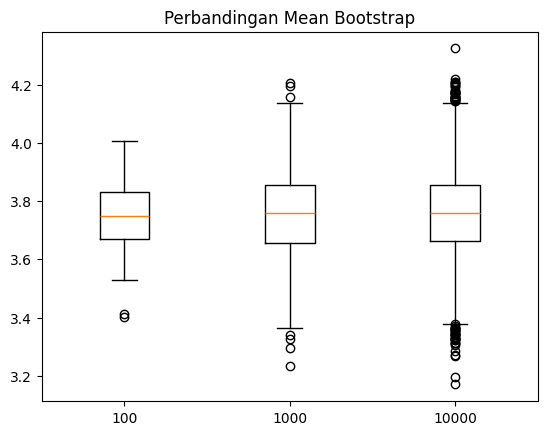

In [16]:
plt.figure()
plt.boxplot([mean_100, mean_1000, mean_10000],
            labels=["100", "1000", "10000"])
plt.title("Perbandingan Mean Bootstrap")
plt.show()

## 4. Interval Kepercayaan 95%

In [17]:
def confidence_interval(data):
    lower = np.percentile(data, 2.5)
    upper = np.percentile(data, 97.5)
    return lower, upper

ci_100 = confidence_interval(mean_100)
ci_1000 = confidence_interval(mean_1000)
ci_10000 = confidence_interval(mean_10000)

print("CI 100 :", ci_100)
print("CI 1000 :", ci_1000)
print("CI 10000 :", ci_10000)

print("\nMean asli :", petal_length.mean())

CI 100 : (np.float64(3.5302499999999997), np.float64(3.9833333333333334))
CI 1000 : (np.float64(3.4686), np.float64(4.039383333333334))
CI 10000 : (np.float64(3.475333333333333), np.float64(4.035333333333333))

Mean asli : 3.7580000000000005


# BAGIAN C - Perbandingan dan Analisis

In [18]:
print("Mean asli :", petal_length.mean())
print("Mean bootstrap 10000 :", np.mean(mean_10000))

Mean asli : 3.7580000000000005
Mean bootstrap 10000 : 3.7588605333333334


Jawaban Konseptual:

1. Ya, mean bootstrap mendekati mean asli.
2. Semakin banyak bootstrap, distribusi semakin halus dan stabil.
3. 10000 paling stabil.
4. Biasanya mean asli berada dalam interval kepercayaan.
5. Karena bootstrap menggunakan sampling dengan pengembalian (replace = true).

# BAGIAN D - Kesimpulan

* EDA menunjukkan bahwa dataset Iris terdiri dari 150 observasi dengan distribusi data yang seimbang pada tiga spesies. Secara umum, variabel petal length dan petal width memiliki variasi paling besar dan menjadi fitur yang paling membedakan antar spesies, sedangkan sepal length dan sepal width cenderung memiliki tumpang tindih antar kelompok. Distribusi data sebagian besar cukup simetris dan tidak ditemukan outlier ekstrem yang signifikan.

* Berdasarkan visualisasi per spesies, Setosa memiliki ukuran petal paling kecil dan terpisah jelas dari dua spesies lainnya, sehingga paling mudah diklasifikasikan. Versicolor berada pada rentang tengah dan memiliki beberapa tumpang tindih dengan Virginica. Virginica memiliki ukuran petal paling besar dengan variasi yang lebih lebar. Secara keseluruhan, pemisahan spesies paling jelas terlihat pada variabel petal.

* Bootstrap dalam analisis ini bermanfaat untuk mengestimasi distribusi sampling dari mean tanpa asumsi distribusi tertentu. Teknik ini memungkinkan perhitungan interval kepercayaan 95% serta menunjukkan bahwa rata-rata hasil bootstrap mendekati mean data asli. Selain itu, bootstrap membantu memahami tingkat kestabilan estimasi melalui proses resampling berulang.

* Dari perbandingan jumlah iterasi, 100 bootstrap masih menghasilkan distribusi yang kurang stabil, 1000 sudah cukup halus dan konsisten, sedangkan 10000 sangat stabil namun membutuhkan komputasi lebih besar. Oleh karena itu, jumlah bootstrap yang cukup dan efisien untuk analisis adalah sekitar 1000 hingga 10000 iterasi.